# Part 1: Fully-Connected Neural Nets with PyTorch

Ensure that PyTorch is installed before this section, as we will utilize this powerful library.

For installation when running locally, check this link - [https://pytorch.org/get-started/locally/](https://pytorch.org/get-started/locally/)

In [116]:
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
from torchvision.ops import MLP

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# TODO: Review PyTorch concepts from HW3

In [117]:
# Load MNIST data and convert to a useful representation. We do this for you,
# but do you understand why these are necessary?
data = datasets.MNIST(root='../data', download=True)
X = data.data
y = data.targets

# Flatten the 28x28 pixel images
X = X.reshape(X.shape[0], -1)

# Encode the target labels into one-hot representations
encoder = OneHotEncoder()
y = encoder.fit_transform(y.reshape(-1, 1)).toarray()

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# TODO: Convert X and y to PyTorch tensors of the appropriate type
#https://stackoverflow.com/questions/56741087/how-to-fix-runtimeerror-expected-object-of-scalar-type-float-but-got-scalar-typ
X = torch.tensor(X, dtype = torch.float32)
y = torch.tensor(y, dtype = torch.float32)

Using device: cuda


In [118]:
# TODO: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



A good example of building neural networks with PyTorch is available at the following link: [https://pytorch.org/tutorials/recipes/recipes/defining_a_neural_network.html](https://pytorch.org/tutorials/recipes/recipes/defining_a_neural_network.html)

In [119]:
# TODO: Define the Fully Connected Neural Network class including an __init__ function and a forward function
class FullyConnectedNN(nn.Module):
    # TODO: create a hidden layer, output layer, and ReLU activation function
    def __init__(self, input_size, hidden_size, output_size):

        super(FullyConnectedNN, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        # Creating hidden layer
        self.hidden_layer = nn.Linear(self.input_size, self.hidden_size)

        # Creating the output layer
        self.output_layer = nn.Linear(self.hidden_size, self.output_size)

    # TODO: pass through the layers, then apply softmax activation function along the correct dimension
    def forward(self, x):
         x = self.hidden_layer(x)
         x = torch.relu(x)

         x = self.output_layer(x)
         output = torch.softmax(x, dim=1)

         return output



In [120]:
# Set model parameters
input_size = X_train.shape[1]

# TODO: Specify the number of neurons in the hidden layer
# What is an appropriate number of neurons? You should experiment until you
# get good accuracy. We will investigate this more in terms of
# underfitting and overfitting in Part 3.
hidden_size = 200

output_size = y_train.shape[1]

# TODO: Specify a good learning rate.
learning_rate = 0.001

In [6]:
# Initialize the model with the specified parameters
model = FullyConnectedNN(input_size, hidden_size, output_size)

# TODO: Define a suitable loss function and an optimizer
# https://docs.pytorch.org/tutorials/recipes/zero_redundancy_optimizer.html
# https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html#torch.nn.CrossEntropyLoss
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [7]:
def train_model(model, X_train, y_train, epochs):
    for epoch in range(epochs):
        optimizer.zero_grad()

        # Forward pass
        y_pred = model(X_train)

        # TODO: Compute loss
        loss = criterion(y_pred, y_train)

        # TODO: Compute the gradient and apply the gradient using the optimizer
        loss.backward()
        optimizer.step()

        # Gather data and print every 100 epochs
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

# Train the model
train_model(model, X_train, y_train, epochs=1000)

Epoch 100/1000, Loss: 1.5269
Epoch 200/1000, Loss: 1.4988
Epoch 300/1000, Loss: 1.4867
Epoch 400/1000, Loss: 1.4796
Epoch 500/1000, Loss: 1.4757
Epoch 600/1000, Loss: 1.4736
Epoch 700/1000, Loss: 1.4721
Epoch 800/1000, Loss: 1.4711
Epoch 900/1000, Loss: 1.4705
Epoch 1000/1000, Loss: 1.4701


In [8]:
# Evaluate the model
def evaluate_model(model, X_test, y_test):
    with torch.no_grad():
        y_pred = model(X_test)
        y_pred_classes = torch.argmax(y_pred, axis=1)
        y_true_classes = torch.argmax(y_test, axis=1)
        accuracy = torch.mean((y_pred_classes == y_true_classes).float()).item()
        return accuracy

# Evaluate on the test set
print( evaluate_model(model, X_test, y_test))

# TODO: If your accuracy is below 0.9 or training is taking a long time,
# experiment with different options for your choices above, or double-check
# your understanding of course materials

0.9682499766349792


# Part 2: Fully-Connected Neural Network using NumPy

To achieve full points for this part, your test data must be predicted with an accuracy of over 90%.
PLEASE CITE ANY ONLINE RESOURCES USED AS A COMMENT IN YOUR CODE

In [9]:
import numpy as np

In [87]:
# TODO: Use data from Part 1, or reload MNIST data in a similar way

X = data.data
y = data.targets

# Flatten the 28x28 pixel images
X = X.reshape(X.shape[0], -1)

# Encode the target labels into one-hot representations
encoder = OneHotEncoder()
y = encoder.fit_transform(y.reshape(-1, 1)).toarray()

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# TODO: Convert X and y to PyTorch tensors of the appropriate type
#https://stackoverflow.com/questions/56741087/how-to-fix-runtimeerror-expected-object-of-scalar-type-float-but-got-scalar-typ

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Using device: cuda


In [11]:
def relu(x):
    # TODO: Implement the ReLU function in numpy
    formula = np.maximum(0, x)
    return formula

def relu_derivative(x):
    # TODO: Implement the derivative of the ReLU function in numpy
    #https://www.bragitoff.com/2021/12/efficient-implementation-of-relu-function-and-its-derivative-gradient-in-python/
    #https://stackoverflow.com/questions/46411180/implement-relu-derivative-in-python-numpy
    derivative = np.greater(x, 0).astype(float)
    return derivative

In [12]:
def softmax(x):
    # TODO: Implement the softmax function
    output = x.copy()

    # For some reason i was getting an overflow so i tried stabilizing the softmax function as suggested on piazza
    exp_x = np.exp(output - np.max(output, axis=1, keepdims=True))

    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [13]:
def compute_loss(y_true, y_pred):
    """Categorical Crossentropy Loss."""
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))


In [14]:
# Define the Fully Connected Network class
class FullyConnectedNN:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        """Initialize the network parameters."""
        self.learning_rate = learning_rate
        # Initialize weights and biases
        self.weights_input_hidden = np.random.randn(input_size, hidden_size) * 0.1
        self.bias_hidden = np.zeros((1, hidden_size))
        self.weights_hidden_output = np.random.randn(hidden_size, output_size) * 0.1
        self.bias_output = np.zeros((1, output_size))

    def forward(self, X):
        """Perform forward propagation."""
        self.input = X

        # TODO: Compute the hidden layer output
        # Combine the inputs (X) and weights_input_hidden, then add the bias for the hidden layer
        self.hidden_input = np.dot(self.input, self.weights_input_hidden) + self.bias_hidden

        # TODO: Apply the ReLU activation function to the hidden layer input to get the hidden layer output
        self.hidden_output = relu(self.hidden_input)

        # TODO: Compute the output layer's output
        # Combine the hidden layer output and weights_hidden_output, then add the bias for the output layer
        self.output_input = np.dot(self.hidden_output, self.weights_hidden_output) + self.bias_output

        # TODO: Apply the softmax function to the output
        self.output = softmax(self.output_input)

        return self.output


    def backward(self, y_true):
        """Perform backward propagation and update parameters."""
        # Calculate gradients for the output layer
        # TODO: get the error in the output layer
        # (HINT: you have already calculated the output (which is the predictions), and you have access to the true labels)
        output_error = self.output - y_true

        # TODO: compute the gradients for the output layer
        # HINT: need to compute the dot product of the hidden layer output and the output error
        # Be careful with the dimensions of the matrices (you may need to transpose one of them)
        d_weights_hidden_output = np.dot(self.hidden_output.T, output_error)

        # TODO: compute the gradients for the output layer bias
        # HINT: the bias is a vector of ones, so you can simply sum the output error

        # NOT summing it into a single number (scalar).
        # Note to self: the output of my nn is basically a matrix of shape (60000, 10). Then All of which probabilities produced from the softmax function.
        # So like: [0.31, 0.39, 0.01, 0.96, ...... 0.31]
        #          [0.98, 0.5, 0.12, 0.01, ...... 0.61]
        # And then i need to sum these into a single VECTOR. Not a scalar.
        d_bias_output = np.sum(output_error, axis=0, keepdims=True)

        # Calculate gradients for the hidden layer
        # TODO: compute the error in the hidden layer
        # HINT: you need to compute the dot product of the output error and the weights_hidden_output and be mindful of the dimensions
        # multiply the result by the derivative of the ReLU function applied to the hidden layer output

        hidden_error = np.dot(output_error, self.weights_hidden_output.T) * relu_derivative(self.hidden_output)

        # TODO: compute the gradients for the hidden layer weights
        # HINT: need to compute the dot product of the input and the hidden error, and be mindful of the dimensions
        d_weights_input_hidden = np.dot(self.input.T, hidden_error)

        # TODO: compute the gradients for the hidden layer bias
        d_bias_hidden = np.sum(hidden_error, axis=0, keepdims=True)

        # TODO: Update weights and biases
        # This will be done using the gradients computed above and the learning rate
        self.weights_hidden_output -= self.learning_rate * d_weights_hidden_output
        self.bias_output -= self.learning_rate * d_bias_output
        self.weights_input_hidden -= self.learning_rate * d_weights_input_hidden
        self.bias_hidden -= self.learning_rate * d_bias_hidden

    def train(self, X, y, epochs):
        """Train the network for a number of epochs."""
        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X)

            # Compute loss
            loss = compute_loss(y, y_pred)

            # Backward pass
            self.backward(y)

            # Print loss every 100 epochs
            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss:.4f}")

    def predict(self, X):
        """Predict the class labels for given inputs."""
        probabilities = self.forward(X)
        return np.argmax(probabilities, axis=1)

In [15]:
# Instantiate and train the network
input_size = X_train.shape[1]
print(input_size)
# TODO: Specify the number of neurons in the hidden layer
hidden_size = 200
print(hidden_size)
output_size = y_train.shape[1]

# TODO: Choose a good learning rate
learning_rate = 0.000001

print(y_train[0])


784
200
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [16]:
nn = FullyConnectedNN(input_size, hidden_size, output_size, learning_rate)
nn.train(X_train, y_train, epochs=1000)

Epoch 100/1000, Loss: 0.4626
Epoch 200/1000, Loss: 0.3498
Epoch 300/1000, Loss: 0.2973
Epoch 400/1000, Loss: 0.2641
Epoch 500/1000, Loss: 0.2397
Epoch 600/1000, Loss: 0.2210
Epoch 700/1000, Loss: 0.2060
Epoch 800/1000, Loss: 0.1933
Epoch 900/1000, Loss: 0.1825
Epoch 1000/1000, Loss: 0.1731


In [17]:
# Evaluate the model on the test set
y_pred = nn.predict(X_test)
y_true = np.argmax(y_test, axis=1)
accuracy = np.mean(y_pred == y_true)
print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.9381


# Part 3: Overfitting and Underfitting

In this section we will experiment with GPUs, Overfitting, and Underfitting.

In [48]:
# TODO: Review documentation about using CUDA for data and neural networks.
# In addition to lecture materials, we recommend the following:
# - Very brief overviews:
#   - https://docs.pytorch.org/tutorials/beginner/blitz/tensor_tutorial.html#tensor-operations
#   - https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html#training-on-gpu
# - More in-depth:
#   - https://docs.pytorch.org/docs/stable/tensor_attributes.html#torch.device
#   - https://docs.pytorch.org/docs/stable/notes/cuda.html

# TODO: Make sure you are using a GPU runtime. Do this using the settings
# at the top of the colab page: Runtime > Change Runtime Type
# You will need to re-run your cells, and make sure that your device is "cuda"
# in the second cell from the top of the page

# TODO: Move the following data to cuda, and take their dot product.
# Ensure that their result also automatically has the device of "cuda"
x = torch.tensor([1, 2, 3, 4, 5])
y = torch.tensor([5, 4, 3, 2, 1])

if torch.cuda.is_available():
    x = x.to('cuda')
    y = y.to('cuda')
dot = torch.dot(x.float(), y.float())

print(f"Device of the dot product: {dot.device}")

print(f"Device of x: {x.device}")
print(f"Device of y: {y.device}")

Device of the dot product: cuda:0
Device of x: cuda:0
Device of y: cuda:0


In [121]:
# The MLP model is a shortcut for specifying the NN you did in Part 1, and it also
# allows for more layers. Specifically, the hidden_channels array specifies
# the number of neurons in each layer (after the input layer), so you can modify
# this array to make wider layers, or add more layers
# This starter model should be roughly the same as your model from above

#https://docs.pytorch.org/docs/stable/notes/cuda.html
#https://docs.pytorch.org/tutorials/beginner/blitz/tensor_tutorial.html#tensor-operations
model = MLP(
    in_channels=input_size,
    hidden_channels=[hidden_size, output_size],
    activation_layer=torch.nn.ReLU,
)

# TODO: Move your data and model from part 1 to the GPU (this should be simple, ~2 lines of code)
model = model.to(device)

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

print(device)


cuda


In [122]:
# TODO: Modify your training and/or evaluation code from above to gather data
# about the accuracy of your model on both the train AND test datasets every
# 100 epochs. It's useful to put this in two arrays, so it can be used
# for plotting below. Train the MLP model using this code, and print out the
# accuracy data

print(X_train.dtype, X_test.dtype, y_train.dtype, y_test.dtype)

training_accuracy = []
test_accuracy = []
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
def train_model_MLP(model, X_train, y_train, epochs):
    for epoch in range(epochs):
        optimizer.zero_grad()

        # Forward pass
        y_pred = model(X_train)

        # TODO: Compute loss
        loss = criterion(y_pred, y_train)

        # TODO: Compute the gradient and apply the gradient using the optimizer
        loss.backward()
        optimizer.step()

        # Gather data and print every 100 epochs
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

            tr_accuracy = evaluate_model(model, X_train, y_train)
            print(f"Train accuracy: {tr_accuracy}")
            training_accuracy.append(tr_accuracy)

            te_accuracy = evaluate_model(model, X_test, y_test)
            print(f"Testing accuracy: {te_accuracy}")
            test_accuracy.append(te_accuracy)

# Train the model
train_model_MLP(model, X_train, y_train, epochs=1000)

torch.float32 torch.float32 torch.float32 torch.float32
Epoch 100/1000, Loss: 0.1438
Train accuracy: 0.9600416421890259
Testing accuracy: 0.9520833492279053
Epoch 200/1000, Loss: 0.0703
Train accuracy: 0.9820207953453064
Testing accuracy: 0.9649166464805603
Epoch 300/1000, Loss: 0.0372
Train accuracy: 0.99197918176651
Testing accuracy: 0.9679166674613953
Epoch 400/1000, Loss: 0.0208
Train accuracy: 0.9968541264533997
Testing accuracy: 0.9700832962989807
Epoch 500/1000, Loss: 0.0124
Train accuracy: 0.9989583492279053
Testing accuracy: 0.9713333249092102
Epoch 600/1000, Loss: 0.0078
Train accuracy: 0.9994791746139526
Testing accuracy: 0.9723333120346069
Epoch 700/1000, Loss: 0.0053
Train accuracy: 0.999833345413208
Testing accuracy: 0.9725832939147949
Epoch 800/1000, Loss: 0.0037
Train accuracy: 0.999958336353302
Testing accuracy: 0.9724999666213989
Epoch 900/1000, Loss: 0.0028
Train accuracy: 0.9999791383743286
Testing accuracy: 0.9729999899864197
Epoch 1000/1000, Loss: 0.0021
Train acc

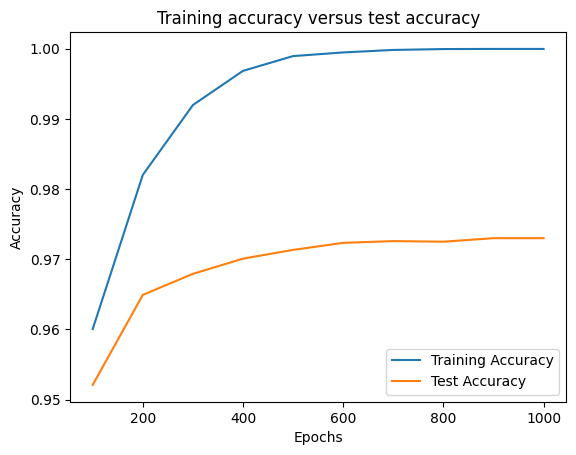

In [123]:
# TODO: Plot train vs. test accuracy for the model above

epochs = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

plt.title('Training accuracy versus test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.plot(epochs, training_accuracy, label="Training Accuracy")
plt.plot(epochs, test_accuracy, label="Test Accuracy")
plt.legend()
plt.show()

In [124]:
# TODO: Find a model that is overfit, plots its accuracy, and explain why you know it's overfitting
# Make sure to train on the GPU!

model_overfit = MLP(
    in_channels=input_size,
    hidden_channels=[2000, output_size],
    activation_layer=torch.nn.ReLU,
)

model_overfit = model_overfit.to(device)

training_accuracy.clear()
test_accuracy.clear()

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model_overfit.parameters(), lr=learning_rate)

train_model_MLP(model_overfit, X_train, y_train, epochs=1000)

Epoch 100/1000, Loss: 0.0462
Train accuracy: 0.9887083172798157
Testing accuracy: 0.9695000052452087
Epoch 200/1000, Loss: 0.0104
Train accuracy: 0.9993333220481873
Testing accuracy: 0.9741666316986084
Epoch 300/1000, Loss: 0.0038
Train accuracy: 0.9999791383743286
Testing accuracy: 0.9755833148956299
Epoch 400/1000, Loss: 0.0019
Train accuracy: 0.9999791383743286
Testing accuracy: 0.9759166836738586
Epoch 500/1000, Loss: 0.0012
Train accuracy: 1.0
Testing accuracy: 0.9761666655540466
Epoch 600/1000, Loss: 0.0008
Train accuracy: 1.0
Testing accuracy: 0.9761666655540466
Epoch 700/1000, Loss: 0.0006
Train accuracy: 1.0
Testing accuracy: 0.9762499928474426
Epoch 800/1000, Loss: 0.0004
Train accuracy: 1.0
Testing accuracy: 0.9764999747276306
Epoch 900/1000, Loss: 0.0003
Train accuracy: 1.0
Testing accuracy: 0.9765833020210266
Epoch 1000/1000, Loss: 0.0003
Train accuracy: 1.0
Testing accuracy: 0.9765833020210266


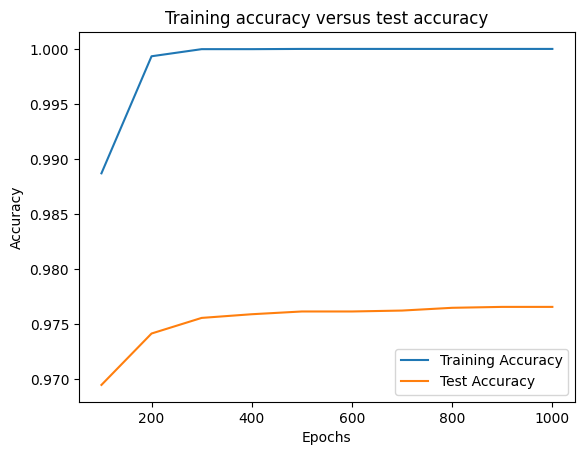

In [125]:
epochs = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

plt.title('Training accuracy versus test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.plot(epochs, training_accuracy, label="Training Accuracy")
plt.plot(epochs, test_accuracy, label="Test Accuracy")
plt.legend()
plt.show()

In [ ]:
# The reason why the test accuracy is so low is because the model trained way too much on the
# training data. It only knows how to fit the training data now. Any new/unseen data will be fit
# to be exactly like the training data. Hence the high Training accuracy and low Test accuracy.

Epoch 100/1000, Loss: 1.7852
Train accuracy: 0.3566249907016754
Testing accuracy: 0.35333332419395447
Epoch 200/1000, Loss: 1.6463
Train accuracy: 0.390708327293396
Testing accuracy: 0.3891666531562805
Epoch 300/1000, Loss: 1.5462
Train accuracy: 0.4092708230018616
Testing accuracy: 0.40625
Epoch 400/1000, Loss: 1.4882
Train accuracy: 0.41583332419395447
Testing accuracy: 0.40958333015441895
Epoch 500/1000, Loss: 1.4310
Train accuracy: 0.43062499165534973
Testing accuracy: 0.42508333921432495
Epoch 600/1000, Loss: 1.3744
Train accuracy: 0.4587083160877228
Testing accuracy: 0.4529166519641876
Epoch 700/1000, Loss: 1.3265
Train accuracy: 0.484604150056839
Testing accuracy: 0.4833333194255829
Epoch 800/1000, Loss: 1.2825
Train accuracy: 0.5020208358764648
Testing accuracy: 0.4984166622161865
Epoch 900/1000, Loss: 1.2487
Train accuracy: 0.5123124718666077
Testing accuracy: 0.5068333148956299
Epoch 1000/1000, Loss: 1.2260
Train accuracy: 0.5192083120346069
Testing accuracy: 0.51241666078567

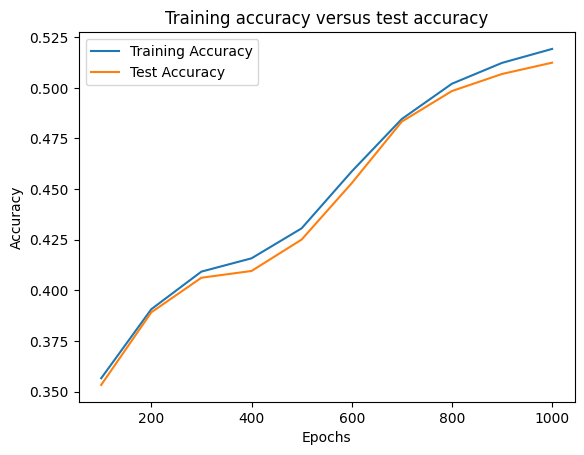

In [126]:
# TODO: Find a model that is underfit, plots its accuracy, and explain why you know it's underfitting

model_underfit = MLP(
    in_channels=input_size,
    hidden_channels=[2, output_size],
    activation_layer=nn.ReLU,
)

model_underfit = model_underfit.to(device)

training_accuracy.clear()
test_accuracy.clear()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_underfit.parameters(), lr=learning_rate)

train_model_MLP(model_underfit, X_train, y_train, epochs=1000)

epochs = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

plt.title('Training accuracy versus test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.plot(epochs, training_accuracy, label="Training Accuracy")
plt.plot(epochs, test_accuracy, label="Test Accuracy")
plt.legend()
plt.show()


# The reason why both training and test accuracies are really low is because there are only two
# neurons in the hidden layer. This gives little processing power for the weights to be fully matured
# and have a good sense of prediction. In other words, the model is underpowered and has bad prediction capability.